<a href="https://colab.research.google.com/github/appsapps555/prj/blob/main/Supplier_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')


# Load the CSV file into a DataFrame
# 手動掛接訓練CSV檔案
# df = pd.read_csv('/content/Data_中英欄位.csv')

df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位.csv')
# df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位_simplifiedFake.csv')
# df
display(df.shape)

print("Displaying the first 10 rows of 'df' to verify column names:")
display(df.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(5200, 57)

Displaying the first 10 rows of 'df' to verify column names:


,PO Number（採購單號）,PO Date（採購單日期）,PO Year（採購年度）,PO Quarter（採購季度）,PO Month（採購月份）,PO Type（採購單類型）,PO Status（採購單狀態）,Supplier ID（供應商編號）,Supplier Name（供應商名稱）,Supplier Country（供應商國家）,...,Contract Start（合約起始日）,Contract End（合約結束日）,Invoice Status（發票狀態）,Payment Status（付款狀態）,Invoice Match Type（發票勾稽類型）,Maverick Spend（脫軌採購）,Single Source Flag（單一來源標記）,Preferred Supplier（優先供應商）,Local International（本地／國際）,Supplier ESG Score（供應商ESG評分）
0,PO-00001,09/05/2024,2024,Q2,May,Standard,Closed,SUP-010,SunRise Manufacturing,South Korea,...,17/09/2023,15/09/2025,Disputed,Paid,3-Way Match,No,No,Yes,International,41.6
1,PO-00002,11/01/2024,2024,Q1,January,Standard,Open,SUP-012,Cornerstone Services,United Kingdom,...,17/01/2023,14/06/2025,Overdue,Overdue,2-Way Match,No,No,No,Local,67.8
2,PO-00003,17/02/2024,2024,Q1,February,Standard,Closed,SUP-015,Iron Gate Steel,Poland,...,17/02/2024,18/03/2024,Overdue,Pending,2-Way Match,No,No,No,International,75.7
3,PO-00004,23/06/2023,2023,Q2,June,Blanket,Closed,SUP-007,Nordic Office Solutions,Sweden,...,23/06/2023,23/07/2023,Disputed,Paid,2-Way Match,No,No,No,International,89.1
4,PO-00005,24/01/2022,2022,Q1,January,Emergency,Open,SUP-002,TechPro Components,Germany,...,03/03/2021,31/01/2023,Pending,Overdue,No Match,No,No,Yes,International,41.4
5,PO-00006,22/12/2024,2024,Q4,December,Contract,Closed,SUP-010,SunRise Manufacturing,South Korea,...,18/10/2024,20/02/2027,Paid,Paid,3-Way Match,No,No,Yes,International,41.6
6,PO-00007,10/03/2023,2023,Q1,March,Contract,Closed,SUP-013,Quantum Electronics,Taiwan,...,10/03/2023,09/04/2023,Paid,Pending,No Match,No,No,No,International,41.5
7,PO-00008,08/11/2023,2023,Q4,November,Standard,Open,SUP-004,FastTrack Logistics,United States,...,12/10/2023,27/02/2026,Pending,On Hold,No Match,No,No,Yes,International,52.3
8,PO-00009,12/08/2022,2022,Q3,August,Standard,Closed,SUP-004,FastTrack Logistics,United States,...,16/01/2022,24/11/2023,Overdue,On Hold,3-Way Match,No,No,Yes,International,52.3
9,PO-00010,10/03/2024,2024,Q1,March,Standard,Closed,SUP-013,Quantum Electronics,Taiwan,...,10/03/2024,09/04/2024,Paid,Paid,3-Way Match,No,No,No,International,41.5


In [13]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define the target variable y
y = df['Supplier Risk（供應商風險等級）']


# Define the features X with only 'Supplier ESG Score（供應商ESG評分）' and 'PO Status（採購單狀態）'
# X_selected = df[['Supplier ESG Score（供應商ESG評分）', 'PO Status（採購單狀態）']]


X_selected = df[['Supplier ESG Score（供應商ESG評分）', 'On Time Delivery（是否準時交貨）',
        'Days Late（延誤天數）',
        # 'PO Status（採購單狀態）'
         ]]

# create fake data for model training
# X_selected = df[['Supplier Risk Fake（供應商風險等級）']]

# Handle categorical features in X_selected by one-hot encoding 'PO Status（採購單狀態）'
categorical_cols_selected = X_selected.select_dtypes(include='object').columns

if not categorical_cols_selected.empty:
    print(f"對以下類別特徵進行獨熱編碼: {list(categorical_cols_selected)}")
    X_selected = pd.get_dummies(X_selected, columns=categorical_cols_selected, drop_first=True)
else:
    print("沒有找到需要進行獨熱編碼的類別特徵。")

# Perform the train-test split (70% training, 30% testing)
# Using stratify=y to maintain the proportion of 'Supplier Risk' classes in both sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y, test_size=0.3, random_state=1, stratify=y
)

print(f"\n選取特徵後的 X 形狀: {X_selected.shape}")
print(f"目標變數 y 形狀: {y.shape}")

print(f"\n訓練特徵集 (X_train_selected) 形狀: {X_train_selected.shape}")
print(f"測試特徵集 (X_test_selected) 形狀: {X_test_selected.shape}")

print(f"訓練目標變數 (y_train_selected) 形狀: {y_train_selected.shape}")
print(f"測試目標變數 (y_test_selected) 形狀: {y_test_selected.shape}")

對以下類別特徵進行獨熱編碼: ['On Time Delivery（是否準時交貨）', 'PO Status（採購單狀態）']

選取特徵後的 X 形狀: (5200, 6)
目標變數 y 形狀: (5200,)

訓練特徵集 (X_train_selected) 形狀: (3640, 6)
測試特徵集 (X_test_selected) 形狀: (1560, 6)
訓練目標變數 (y_train_selected) 形狀: (3640,)
測試目標變數 (y_test_selected) 形狀: (1560,)


### 使用 `X_selected` 訓練模型並評估結果

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 特徵縮放 (Feature Scaling)
# Logistic Regression 對於未縮放的特徵比較敏感。
print("開始進行特徵標準化 (X_selected)...")
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)
print("特徵標準化完成。")



'''
# 2. 初始化邏輯回歸模型
#   - max_iter: 增加迭代次數以確保模型收斂，避免 ConvergenceWarning。
#   - class_weight='balanced': 自動調整類別權重，以應對類別不平衡問題。
model_selected = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')

# 3. 訓練模型
print("\n開始訓練 Logistic Regression 模型 (使用 X_selected)...")
model_selected.fit(X_train_selected_scaled, y_train_selected)
print("模型訓練完成。")

# 4. 進行預測
y_pred_selected = model_selected.predict(X_test_selected_scaled)

# 5. 評估模型性能
print("\n--- 模型評估 (使用 X_selected) ---")

# 準確度
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
print(f"準確度 (Accuracy): {accuracy_selected:.4f}")

# 分類報告 (包含精確度、召回率、F1-score)
print("\n分類報告 (Classification Report):\n")
print(classification_report(y_test_selected, y_pred_selected))

# 混淆矩陣
print("\n混淆矩陣 (Confusion Matrix):\n")
cm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model_selected.classes_)
display_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selected, display_labels=model_selected.classes_)
display_cm_selected.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression (X_selected)')
plt.show()
'''

開始進行特徵標準化 (X_selected)...
特徵標準化完成。


'\n# 2. 初始化邏輯回歸模型\n#   - max_iter: 增加迭代次數以確保模型收斂，避免 ConvergenceWarning。\n#   - class_weight=\'balanced\': 自動調整類別權重，以應對類別不平衡問題。\nmodel_selected = LogisticRegression(max_iter=5000, random_state=42, class_weight=\'balanced\')\n\n# 3. 訓練模型\nprint("\n開始訓練 Logistic Regression 模型 (使用 X_selected)...")\nmodel_selected.fit(X_train_selected_scaled, y_train_selected)\nprint("模型訓練完成。")\n\n# 4. 進行預測\ny_pred_selected = model_selected.predict(X_test_selected_scaled)\n\n# 5. 評估模型性能\nprint("\n--- 模型評估 (使用 X_selected) ---")\n\n# 準確度\naccuracy_selected = accuracy_score(y_test_selected, y_pred_selected)\nprint(f"準確度 (Accuracy): {accuracy_selected:.4f}")\n\n# 分類報告 (包含精確度、召回率、F1-score)\nprint("\n分類報告 (Classification Report):\n")\nprint(classification_report(y_test_selected, y_pred_selected))\n\n# 混淆矩陣\nprint("\n混淆矩陣 (Confusion Matrix):\n")\ncm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model_selected.classes_)\ndisplay_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selecte

### 邏輯回歸模型

In [8]:
# 2. 初始化邏輯回歸模型
#   - max_iter: 增加迭代次數以確保模型收斂，避免 ConvergenceWarning。
#   - class_weight='balanced': 自動調整類別權重，以應對類別不平衡問題。
# model_selected = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
lr_model = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')

# 3. 訓練模型
print("\n開始訓練 Logistic Regression 模型 (使用 X_selected)...")
# model_selected.fit(X_train_selected_scaled, y_train_selected)
lr_model.fit(X_train_selected_scaled, y_train_selected)
print("模型訓練完成。")

# 4. 進行預測
# y_pred_selected = model_selected.predict(X_test_selected_scaled)
y_pred_selected = lr_model.predict(X_test_selected_scaled)



開始訓練 Logistic Regression 模型 (使用 X_selected)...
模型訓練完成。


### 隨機森林模型

In [15]:
# 使用隨機森林
from sklearn.ensemble import RandomForestClassifier

'''
# 初始化隨機森林模型
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
'''

# 建議調優參數組合
rf_model = RandomForestClassifier(
    n_estimators=200,      # 增加樹的數量，提升穩定性
    max_depth=10,          # 限制樹的深度，防止過度擬合 (可嘗試 5~15)
    min_samples_split=5,   # 節點分割所需的最小樣本數
    class_weight='balanced_subsample', # 比 'balanced' 更適合隨機森林的抽樣特性
    random_state=42
)

# 訓練
rf_model.fit(X_train_selected_scaled, y_train_selected)

# 預測與評估
y_pred_selected = rf_model.predict(X_test_selected_scaled)

### 評估模型性能


--- 模型評估 (使用 X_selected) ---
準確度 (Accuracy): 0.9731

分類報告 (Classification Report):

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       105
         Low       1.00      0.96      0.98       923
      Medium       0.93      1.00      0.96       532

    accuracy                           0.97      1560
   macro avg       0.98      0.98      0.98      1560
weighted avg       0.97      0.97      0.97      1560


混淆矩陣 (Confusion Matrix):



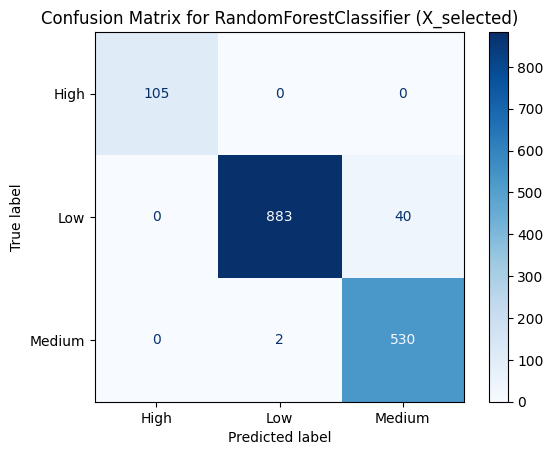

In [16]:
# 5. 評估模型性能
print("\n--- 模型評估 (使用 X_selected) ---")

# 準確度
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
print(f"準確度 (Accuracy): {accuracy_selected:.4f}")

# 分類報告 (包含精確度、召回率、F1-score)
print("\n分類報告 (Classification Report):\n")
print(classification_report(y_test_selected, y_pred_selected))

# 混淆矩陣
print("\n混淆矩陣 (Confusion Matrix):\n")

# model selection:
model=lr_model
# model=rf_model

# cm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model_selected.classes_)
cm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model.classes_)

# display_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selected, display_labels=model_selected.classes_)
display_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selected, display_labels=model.classes_)
display_cm_selected.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for RandomForestClassifier (X_selected)')
plt.show()

### 預測最有貢獻的特徵圖表

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20379 (\N{CJK UNIFIED IDEOGRAPH-4F9B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25033 (\N{CJK UNIFIED IDEOGRAPH-61C9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21830 (\N{CJK UNIFIED IDEOGRAPH-5546}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35413 (\N{CJK UNIFIED IDEOGRAPH-8A55}) missing from font(s) DejaVu Sans.
  fig.canvas

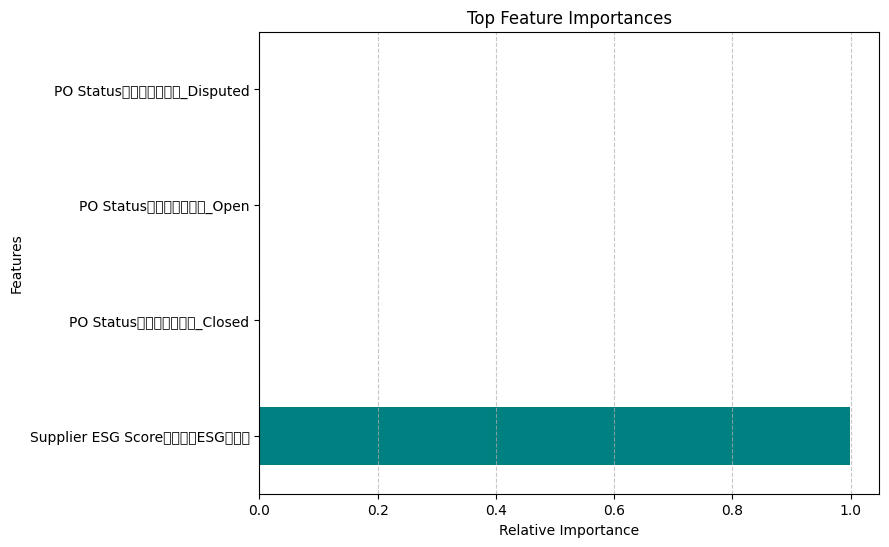

各特徵重要性數值：
Supplier ESG Score（供應商ESG評分）    0.998237
PO Status（採購單狀態）_Closed         0.000679
PO Status（採購單狀態）_Open           0.000598
PO Status（採購單狀態）_Disputed       0.000486
dtype: float64


"import pandas as pd\nimport matplotlib.pyplot as plt\n\nimportances = pd.Series(rf_model.feature_importances_, index=X_selected.columns)\nimportances.nlargest(10).plot(kind='barh')\nplt.title('Feature Importance')\nplt.show()\n"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 取得特徵重要性 (Feature Importances)
# 注意：X_selected 是你原始的 DataFrame 欄位名稱
importances = pd.Series(rf_model.feature_importances_, index=X_selected.columns)

# 繪製前 10 大重要特徵
plt.figure(figsize=(8, 6))
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 顯示具體數值
print("各特徵重要性數值：")
print(importances.sort_values(ascending=False))

'''import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=X_selected.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Feature Importance')
plt.show()
'''

### 檢查訓練數據集 (`df_train`) 中的缺失值

In [ ]:
# 檢查 df 中的缺失值
print(df.isnull().sum())

# (可選) 顯示 df_train 中缺失值的百分比
print('\ndf_train 中缺失值的百分比:')
print((df.isnull().sum() / len(df)) * 100)

Supplier Risk（供應商風險等級）         0
Supplier Risk Fake（供應商風險等級）    0
dtype: int64

df_train 中缺失值的百分比:
Supplier Risk（供應商風險等級）         0.0
Supplier Risk Fake（供應商風險等級）    0.0
dtype: float64


### 繪製 `df_train` 中 'Unit Price' 與 'Quantity' 的散佈圖

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Unit Price（單價）', y='Quantity（數量）', data=df, alpha=0.6)
plt.title('Unit Price vs. Quantity in Training Data')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

ValueError: Could not interpret value `Unit Price（單價）` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x700 with 0 Axes>

### 針對 'Unit Price' 與 'Quantity' 欄位進行異常值 (Outliers) 檢測

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 檢測 'Unit Price' 的異常值
unit_price_outliers, up_lower, up_upper = detect_outliers_iqr(df_train, 'Unit Price（單價）')
print(f"'Unit Price' 異常值的數量: {len(unit_price_outliers)}")
print(f"'Unit Price' 下限: {up_lower}, 上限: {up_upper}")
display(unit_price_outliers[['Unit Price（單價）', 'Quantity（數量）']].head())

# 檢測 'Quantity' 的異常值
quantity_outliers, q_lower, q_upper = detect_outliers_iqr(df_train, 'Quantity（數量）')
print(f"\n'Quantity' 異常值的數量: {len(quantity_outliers)}")
print(f"'Quantity' 下限: {q_lower}, 上限: {q_upper}")
display(quantity_outliers[['Unit Price（單價）', 'Quantity（數量）']].head())

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

### Check for Missing Values

In [ ]:
# import pandas as pd
# df = pd.read_csv('/content/drive/MyDrive/專題/Data_中英欄位_simplified.csv')
print(df.isnull().sum())

# Optional: Display percentage of missing values
print('\nPercentage of missing values:')
print((df.isnull().sum() / len(df)) * 100)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

# Assuming 'df' DataFrame is already loaded and available from previous cells.
# If not, please ensure the cell loading the DataFrame (e.g., cell a17dce57) is executed first.

# Define normalization and standardization functions
def min_max_normalize(series):
    if series.empty or series.nunique() == 1:
        return series # Return original if empty or only one unique value
    scaler = MinMaxScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

def z_score_standardize(series):
    if series.empty or series.std() == 0:
        return series # Return original if empty or standard deviation is zero
    scaler = StandardScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)
'''
'Supplier ESG Score（供應商ESG評分）': 對此數值欄位同時應用了最小-最大正規化 (Supplier ESG Score_Normalized) 和 Z-score 標準化 (Supplier ESG Score_Standardized)，並顯示了前幾行結果。
'Days Late（延誤天數）': 對此數值欄位也同時應用了最小-最大正規化 (Days Late_Normalized) 和 Z-score 標準化 (Days Late_Standardized)，並顯示了前幾行結果。
'On Time Delivery（是否準時交貨）': 這是一個二元類別欄位 (Yes/No)。首先，它被轉換為數值型態 (Yes 為 1，No 為 0) 並儲存在 On Time Delivery_Encoded 欄位中。然後，對這個編碼後的欄位應用了正規化 (On Time Delivery_Normalized) 和標準化 (On Time Delivery_Standardized)，並顯示了前幾行結果。
'PO Status（採購單狀態）', 'Invoice Status（發票狀態）', 'Payment Status（付款狀態）': 這些是多類別名目欄位。程式碼對它們應用了獨熱編碼 (One-Hot Encoding)。這將每個類別轉換為一個新的二元 (0 或 1) 欄位。例如，'PO Status（採購單狀態）' 會被轉換為 PO Status_Cancelled, PO Status_Closed 等欄位，每個欄位表示原始類別是否存在。獨熱編碼後的結果也顯示了前幾行。
'''

print("--- Processing 'Supplier ESG Score（供應商ESG評分）' ---")
df['Supplier ESG Score_Normalized'] = min_max_normalize(df['Supplier ESG Score（供應商ESG評分）'])
df['Supplier ESG Score_Standardized'] = z_score_standardize(df['Supplier ESG Score（供應商ESG評分）'])
display(df[['Supplier ESG Score（供應商ESG評分）', 'Supplier ESG Score_Normalized', 'Supplier ESG Score_Standardized']].head())

print("\n--- Processing 'Days Late（延誤天數）' ---")
df['Days Late_Normalized'] = min_max_normalize(df['Days Late（延誤天數）'])
df['Days Late_Standardized'] = z_score_standardize(df['Days Late（延誤天數）'])
display(df[['Days Late（延誤天數）', 'Days Late_Normalized', 'Days Late_Standardized']].head())

print("\n--- Processing 'On Time Delivery（是否準時交貨）' ---")
# Convert binary categorical to numerical (0/1)
df['On Time Delivery_Encoded'] = df['On Time Delivery（是否準時交貨）'].map({'Yes': 1, 'No': 0})
# Apply normalization and standardization to the encoded column
df['On Time Delivery_Normalized'] = min_max_normalize(df['On Time Delivery_Encoded'])
df['On Time Delivery_Standardized'] = z_score_standardize(df['On Time Delivery_Encoded'])
display(df[['On Time Delivery（是否準時交貨）', 'On Time Delivery_Encoded', 'On Time Delivery_Normalized', 'On Time Delivery_Standardized']].head())

print("\n--- Processing 'PO Status（採購單狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['PO Status（採購單狀態）'], prefix='PO Status')], axis=1)
display(df[[col for col in df.columns if 'PO Status' in col]].head())

print("\n--- Processing 'Invoice Status（發票狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['Invoice Status（發票狀態）'], prefix='Invoice Status')], axis=1)
display(df[[col for col in df.columns if 'Invoice Status' in col]].head())

print("\n--- Processing 'Payment Status（付款狀態）' (One-Hot Encoding) ---")
df = pd.concat([df, pd.get_dummies(df['Payment Status（付款狀態）'], prefix='Payment Status')], axis=1)
display(df[[col for col in df.columns if 'Payment Status' in col]].head())

### Standardization and Normalization

In [ ]:
'''
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Function for Min-Max Normalization
def min_max_normalize(series):
    scaler = MinMaxScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

# Function for Z-score Standardization
def z_score_standardize(series):
    scaler = StandardScaler()
    return pd.Series(scaler.fit_transform(series.values.reshape(-1, 1)).flatten(), index=series.index)

# Example usage: Normalize 'Unit Price（單價）' column
df['Unit Price_Normalized'] = min_max_normalize(df['Unit Price（單價）'])
display(df[['Unit Price（單價）', 'Unit Price_Normalized']].head())

# Example usage: Standardize 'Quantity（數量）' column
df['Quantity_Standardized'] = z_score_standardize(df['Quantity（數量）'])
display(df[['Quantity（數量）', 'Quantity_Standardized']].head())
'''

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

### Display the first 5 rows of the DataFrame

In [ ]:
# display(df.head())

### Display DataFrame information (column names, non-null counts, data types)

In [ ]:
df.info()

### Display descriptive statistics for numerical columns

In [ ]:
display(df.describe())

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# Display descriptive statistics of 'Contract Type' grouped by 'Supplier Risk'
# display(df.groupby('Supplier Risk（供應商風險等級）')['Contract Type（合約類型）'].describe())

# Box plot to visualize the distribution of 'Contract Term' across 'Supplier Risk' categories
plt.figure(figsize=(10, 7))
# sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Contract Term（合約期限）', data=df, palette='viridis')
sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Contract Type（合約類型）', data=df, palette='viridis')

plt.title('Contract Type Distribution by Supplier Risk Level')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Contract Type')
plt.show()

### Analyze 'Supplier Risk（供應商風險等級）' Distribution

Supplier Risk Distribution:
 Supplier Risk（供應商風險等級）
Low       609
Medium    319
High       71
Name: count, dtype: int64


/tmp/ipykernel_1287/1632704671.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='viridis')


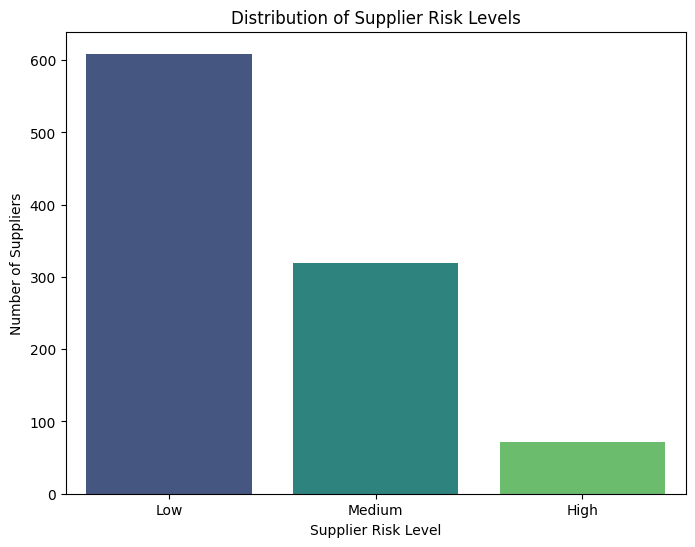

In [ ]:
# Get value counts for 'Supplier Risk'
risk_counts = df['Supplier Risk（供應商風險等級）'].value_counts()
print('Supplier Risk Distribution:\n', risk_counts)

# Plot the distribution of 'Supplier Risk'
plt.figure(figsize=(8, 6))
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='viridis')
plt.title('Distribution of Supplier Risk Levels')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Number of Suppliers')
plt.show()

### Correlation Heatmap of Numerical Features

In [ ]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
# Plot the distribution of 'Supplier ESG Score'
plt.figure(figsize=(10, 6))
sns.histplot(df['Supplier ESG Score（供應商ESG評分）'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Supplier ESG Score')
plt.xlabel('Supplier ESG Score')
plt.ylabel('Frequency')
plt.show()

# Add a scatter plot of 'Supplier ESG Score' vs. 'Days Late'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Days Late（延誤天數）', y='Supplier ESG Score（供應商ESG評分）', data=df, alpha=0.6)
plt.title('Supplier ESG Score vs. Days Late')
plt.xlabel('Days Late')
plt.ylabel('Supplier ESG Score')
plt.grid(True)
plt.show()

### Analyze 'Supplier ESG Score（供應商ESG評分）' Distribution

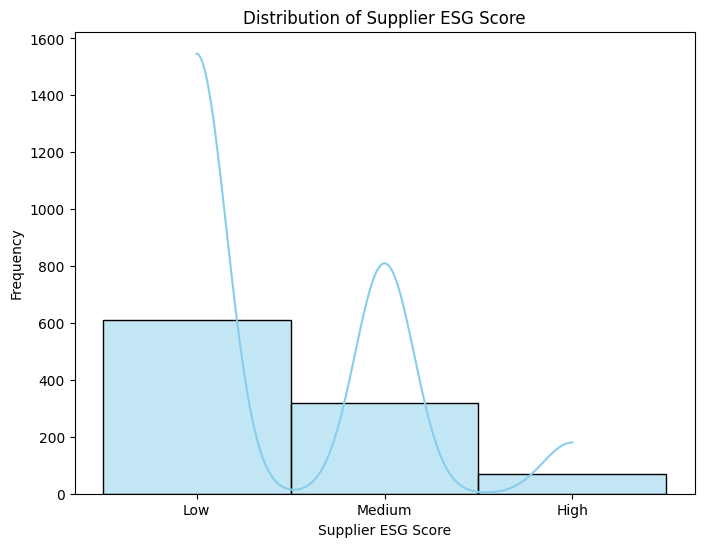

In [ ]:
# Plot the distribution of 'Supplier ESG Score'
plt.figure(figsize=(8, 6))
sns.histplot(df['Supplier Risk（供應商風險等級）'], bins=20, kde=True, color='skyblue')
# Supplier ESG Score（供應商ESG評分）

plt.title('Distribution of Supplier ESG Score')
plt.xlabel('Supplier ESG Score')
plt.ylabel('Frequency')
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Supplier ESG Score（供應商ESG評分）'

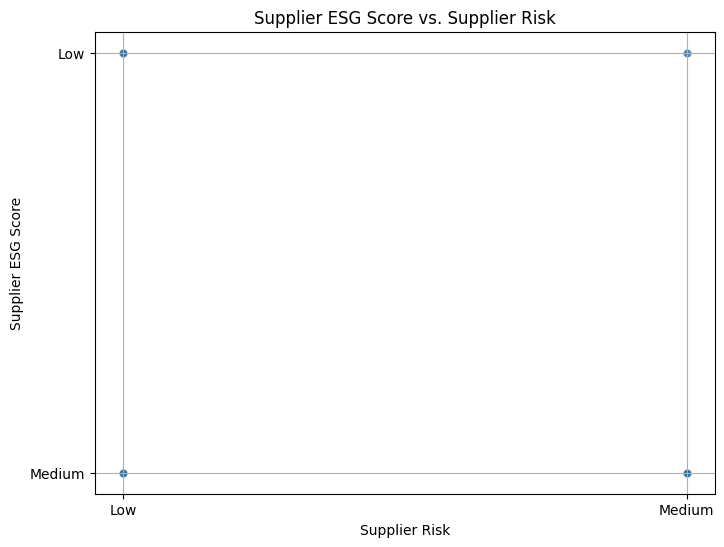

"\n# Box plot to visualize the distribution of 'Supplier ESG Score' across 'Supplier Risk' categories\nplt.figure(figsize=(8, 7))\nsns.boxplot(x='Supplier Risk（供應商風險等級）', y='Supplier ESG Score（供應商ESG評分）', data=df, palette='viridis')\nplt.title('Supplier ESG Score Distribution by Supplier Risk Level')\nplt.xlabel('Supplier Risk Level')\nplt.ylabel('Supplier ESG Score')\nplt.show()\n"

In [ ]:
# Add a scatter plot of 'Supplier ESG Score' vs. 'Supplier Risk'
plt.figure(figsize=(8, 6))
# sns.scatterplot(x='Supplier Risk（供應商風險等級）', y='Supplier ESG Score（供應商ESG評分）', data=df, alpha=0.6)

sns.scatterplot(x='Supplier Risk（供應商風險等級）', y='Supplier Risk Fake（供應商風險等級）', data=df, alpha=0.6)


plt.title('Supplier ESG Score vs. Supplier Risk')
plt.xlabel('Supplier Risk')
plt.ylabel('Supplier ESG Score')
plt.grid(True)
plt.show()

'''
# Box plot to visualize the distribution of 'Supplier ESG Score' across 'Supplier Risk' categories
plt.figure(figsize=(8, 7))
sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Supplier ESG Score（供應商ESG評分）', data=df, palette='viridis')
plt.title('Supplier ESG Score Distribution by Supplier Risk Level')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Supplier ESG Score')
plt.show()
'''

In [ ]:
'''Using crosstab plot'''

# Create a cross-tabulation of 'Supplier Risk' and 'Supplier ESG Score'
crosstab_po_type = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Supplier ESG Score（供應商ESG評分）'])
display(crosstab_po_type)

# Visualize the relationship with a stacked bar plot
crosstab_po_type.plot(kind='bar', stacked=True, figsize=(8, 7))
plt.title('Supplier Risk by ESG Score')
plt.xlabel('Supplier Risk')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Supplier ESG Score')
plt.tight_layout()
plt.show()

### Relationship between 'PO Status（採購單狀態）' and 'PO Type（採購單類型）'

In [ ]:
'''
# Create a cross-tabulation of 'PO Status' and 'PO Type'
crosstab_po_type = pd.crosstab(df['PO Status（採購單狀態）'], df['PO Type（採購單類型）'])
display(crosstab_po_type)

# Visualize the relationship with a stacked bar plot
crosstab_po_type.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('PO Status by PO Type')
plt.xlabel('PO Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='PO Type')
plt.tight_layout()
plt.show()'''

### 顯示訓練數據集 (`df_train`) 的描述性統計資訊

In [ ]:
display(df_train.describe())

# 不適合使用PO Status作為Y應變數的原因

In [ ]:
# Get value counts for 'PO Status'
po_status_counts = df['PO Status（採購單狀態）'].value_counts()
print('PO Status Distribution:\n', po_status_counts)

# Plot the distribution of 'PO Status'
plt.figure(figsize=(8, 6))
sns.barplot(x=po_status_counts.index, y=po_status_counts.values, palette='coolwarm')
plt.title('Distribution of PO Status')
plt.xlabel('PO Status')
plt.ylabel('Number of Purchase Orders')
plt.show()



# Add a scatter plot of 'Supplier ESG Score' vs. 'Days Late'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Supplier Risk（供應商風險等級）', y='PO Status（採購單狀態）', data=df, alpha=0.6)
plt.title('PO Status vs. Supplier Risk')
plt.xlabel('Supplier Risk')
plt.ylabel('PO Status')
plt.grid(True)
plt.show()

### Analyze 'Days Late（延誤天數）' Distribution

In [ ]:
# Get value counts for 'Days Late（延誤天數）'
po_status_counts = df['Days Late（延誤天數）'].value_counts()
print('Days Late Distribution:\n', po_status_counts)

# Plot the distribution of 'Days Late'
plt.figure(figsize=(8, 6))
sns.barplot(x=po_status_counts.index, y=po_status_counts.values, palette='coolwarm')
plt.title('Distribution of Days Late')
plt.xlabel('Days Late')
plt.ylabel('Number of Purchase Orders')
plt.show()

In [ ]:
'''
# Get value counts for 'Days Late（延誤天數）'
days_late_cnt = df['Days Late（延誤天數）'].value_counts()
print('Days Late Distribution:\n', days_late_cnt)
'''


# Plot the distribution of 'Days Late'
plt.figure(figsize=(8, 6))
sns.histplot(df['Days Late（延誤天數）'], bins=40, kde=True, color='lightcoral')
plt.title('Distribution of Days Late')
plt.xlabel('Days Late')
plt.ylabel('Frequency')
plt.show()



### Relationship between 'Supplier Risk（供應商風險等級）' and 'Days Late（延誤天數）'

In [ ]:
# Add a scatter plot of 'Supplier ESG Score' vs. 'Days Late'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Days Late（延誤天數）', y='Supplier Risk（供應商風險等級）', data=df, alpha=0.6)
plt.title('Supplier Risk vs. Days Late')
plt.xlabel('Days Late')
plt.ylabel('Supplier Risk')
plt.grid(True)
plt.show()


# Box plot to visualize the distribution of 'Days Late' across 'Supplier Risk' categories
plt.figure(figsize=(10, 7))
sns.boxplot(x='Supplier Risk（供應商風險等級）', y='Days Late（延誤天數）', data=df, palette='coolwarm')
plt.title('Days Late Distribution by Supplier Risk Level')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Days Late')
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'On Time Delivery（是否準時交貨）'

In [ ]:
# Cross-tabulation
crosstab_on_time = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['On Time Delivery（是否準時交貨）'])
display(crosstab_on_time)

# Stacked bar chart
crosstab_on_time.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by On Time Delivery')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='On Time Delivery')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'PO Status（採購單狀態）'

In [ ]:
# Cross-tabulation
crosstab_po_status = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['PO Status（採購單狀態）'])
display(crosstab_po_status)

# Stacked bar chart
crosstab_po_status.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by PO Status')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='PO Status')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Invoice Status（發票狀態）'

In [ ]:
# Cross-tabulation
crosstab_invoice_status = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Invoice Status（發票狀態）'])
display(crosstab_invoice_status)

# Stacked bar chart
crosstab_invoice_status.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Invoice Status')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Invoice Status')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Payment Status（付款狀態）'

In [ ]:
# Cross-tabulation
crosstab_payment_status = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Payment Status（付款狀態）'])
display(crosstab_payment_status)

# Stacked bar chart
crosstab_payment_status.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Payment Status')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Payment Status')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Supplier Tier（供應商層級）'

In [ ]:
# Cross-tabulation
crosstab_supplier_tier = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Supplier Tier（供應商層級）'])
display(crosstab_supplier_tier)

# Stacked bar chart
crosstab_supplier_tier.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Supplier Tier')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Supplier Tier')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Maverick Spend（脫軌採購）'

In [ ]:
# Cross-tabulation
crosstab_maverick = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Maverick Spend（脫軌採購）'])
display(crosstab_maverick)

# Stacked bar chart
crosstab_maverick.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Maverick Spend')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Maverick Spend')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Single Source Flag（單一來源標記）'

In [ ]:
# Cross-tabulation
crosstab_single_source = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Single Source Flag（單一來源標記）'])
display(crosstab_single_source)

# Stacked bar chart
crosstab_single_source.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Single Source Flag')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Single Source Flag')
plt.tight_layout()
plt.show()

### Relationship between 'Supplier Risk（供應商風險等級）' and 'Preferred Supplier（優先供應商）'

In [ ]:
# Cross-tabulation
crosstab_preferred = pd.crosstab(df['Supplier Risk（供應商風險等級）'], df['Preferred Supplier（優先供應商）'])
display(crosstab_preferred)

# Stacked bar chart
crosstab_preferred.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Supplier Risk Level by Preferred Supplier')
plt.xlabel('Supplier Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Preferred Supplier')
plt.tight_layout()
plt.show()